## Homework 4
ELENE4730 Quantum Optimization and Machine Learning

Daniel Vitenko

In [2]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
ibmsampler = Sampler(mode=backend)


qiskit_runtime_service.__init__:WARNING:2026-02-28 16:48:26,190: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-28 16:48:27,514: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-28 16:48:30,483: Using instance: open-instance, plan: open


## 1b.

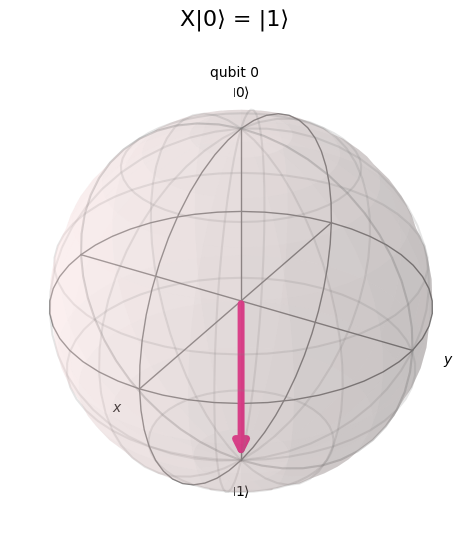

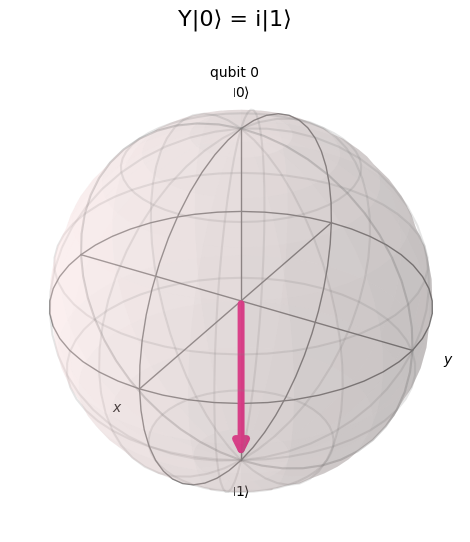

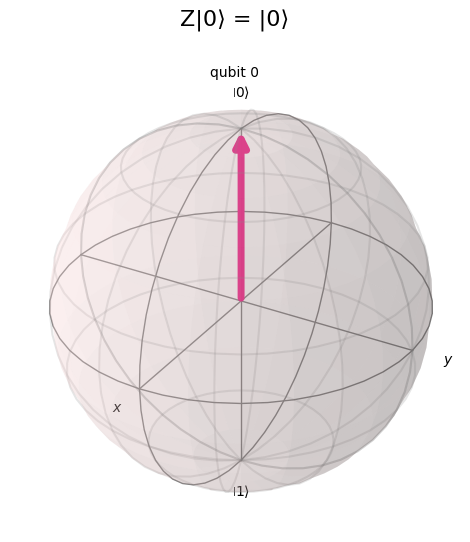

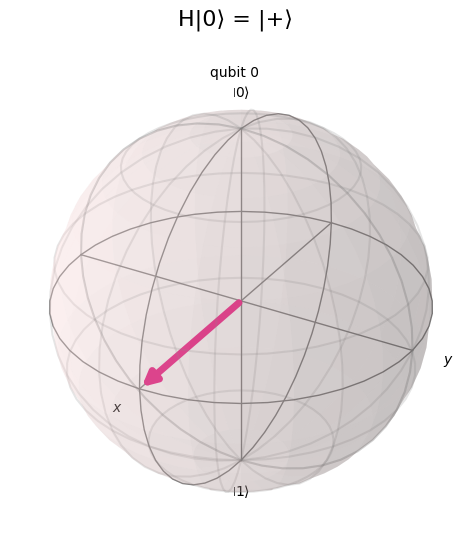

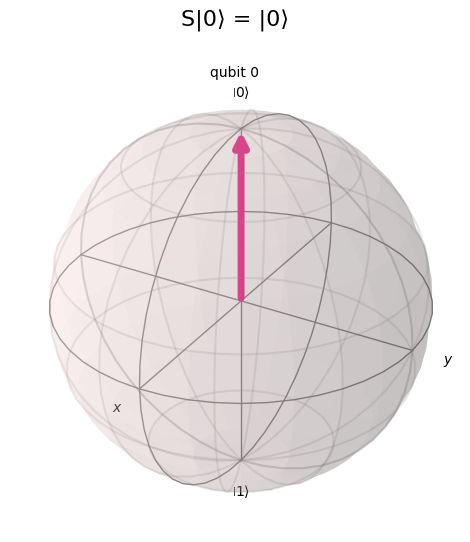

In [ ]:
qc = QuantumCircuit(1)
qc.x(0)

plot_bloch_multivector(Statevector(qc), title="X|0⟩ = |1⟩")

qc = QuantumCircuit(1)
qc.y(0)

plot_bloch_multivector(Statevector(qc), title="Y|0⟩ = i|1⟩")

qc = QuantumCircuit(1)
qc.z(0)

plot_bloch_multivector(Statevector(qc), title="Z|0⟩ = |0⟩")

qc = QuantumCircuit(1)
qc.h(0)

plot_bloch_multivector(Statevector(qc), title="H|0⟩ = |+⟩")

qc = QuantumCircuit(1)
qc.s(0)

plot_bloch_multivector(Statevector(qc), title="S|0⟩ = |0⟩")

plt.show()

## 1d.

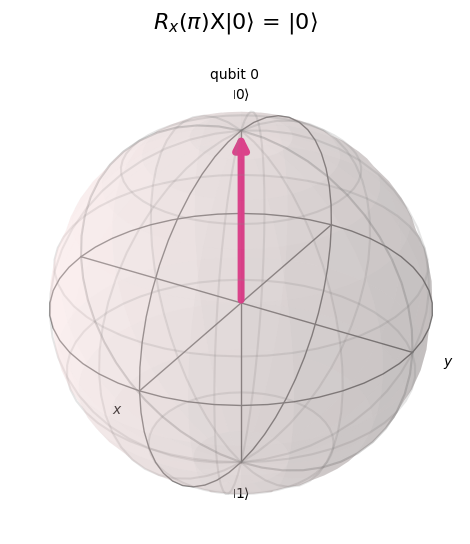

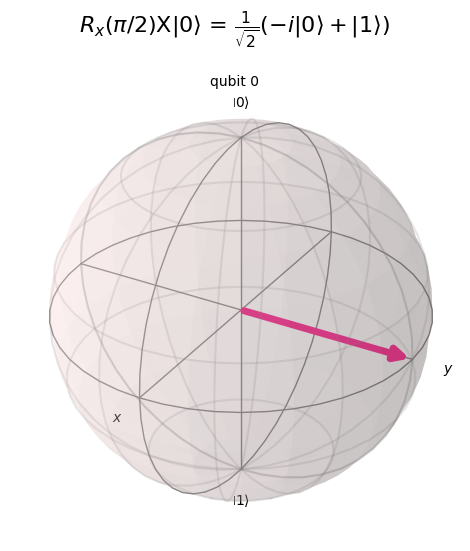

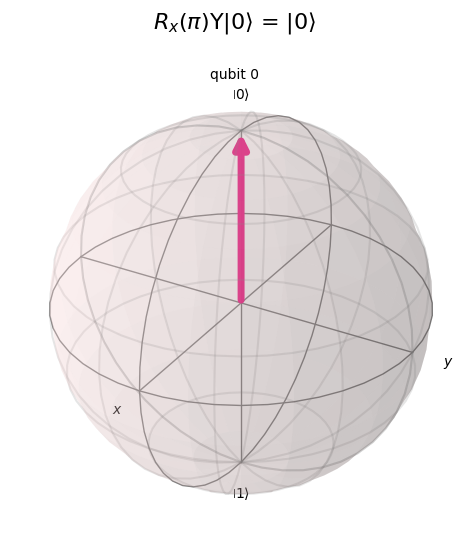

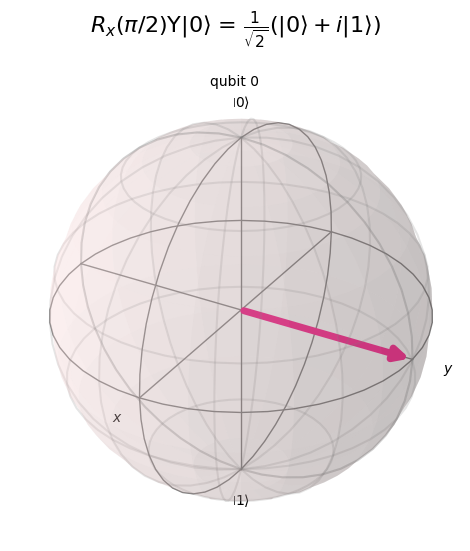

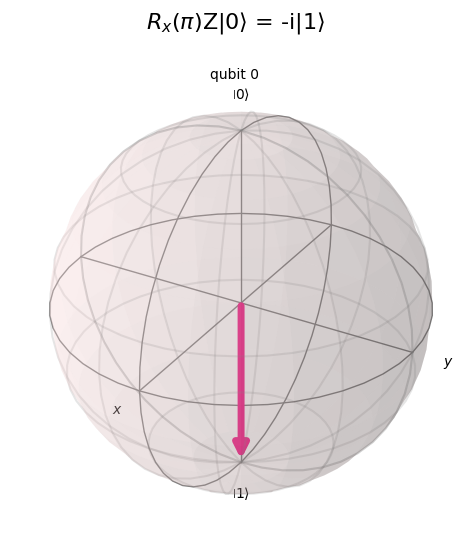

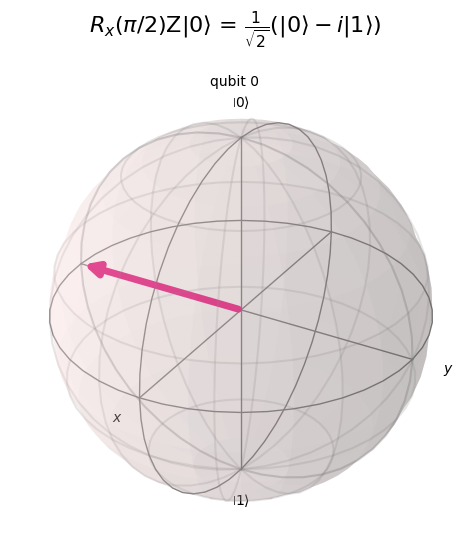

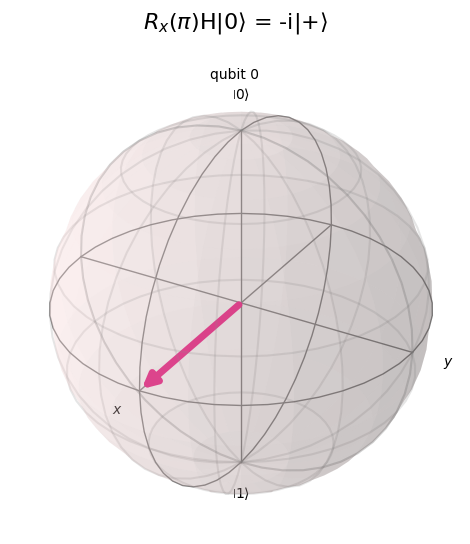

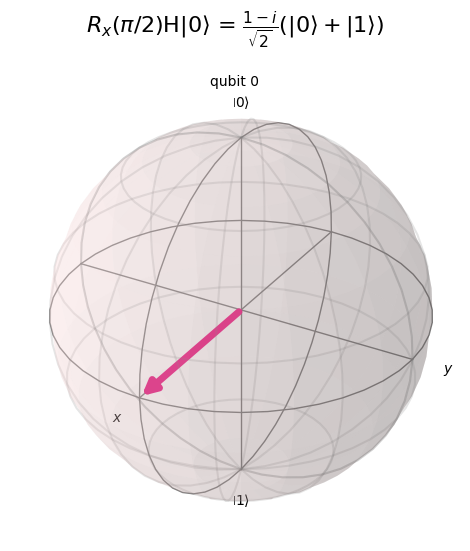

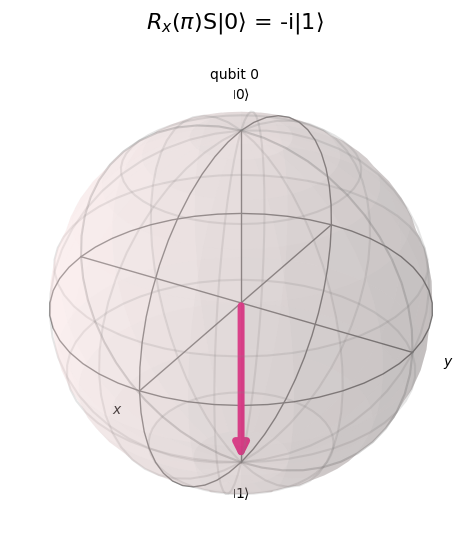

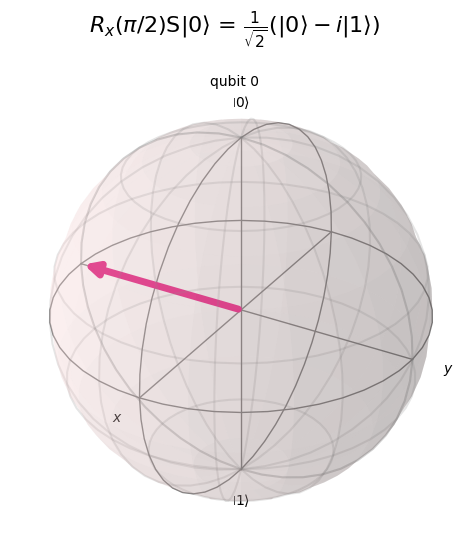

In [17]:
# After X
qc = QuantumCircuit(1)
qc.x(0)
qc.rx(np.pi, 0)

plot_bloch_multivector(Statevector(qc), title="$R_x(\\pi)$X|0⟩ = |0⟩")

qc = QuantumCircuit(1)
qc.x(0)
qc.rx(np.pi/2, 0)

plot_bloch_multivector(Statevector(qc), title="$R_x(\\pi/2)$X|0⟩ = $\\frac{1}{\\sqrt{2}}(-i|0⟩ + |1⟩)$")

# After Y
qc = QuantumCircuit(1)
qc.y(0)
qc.rx(np.pi, 0)

plot_bloch_multivector(Statevector(qc), title="$R_x(\\pi)$Y|0⟩ = |0⟩")

qc = QuantumCircuit(1)
qc.y(0)
qc.rx(np.pi/2, 0)

plot_bloch_multivector(Statevector(qc), title="$R_x(\\pi/2)$Y|0⟩ = $\\frac{1}{\\sqrt{2}}(|0⟩ + i|1⟩)$")

# After Z
qc = QuantumCircuit(1)
qc.z(0)
qc.rx(np.pi, 0)

plot_bloch_multivector(Statevector(qc), title="$R_x(\\pi)$Z|0⟩ = -i|1⟩")

qc = QuantumCircuit(1)
qc.z(0)
qc.rx(np.pi/2, 0)

plot_bloch_multivector(Statevector(qc), title="$R_x(\\pi/2)$Z|0⟩ = $\\frac{1}{\\sqrt{2}}(|0⟩ - i|1⟩)$")

# After H
qc = QuantumCircuit(1)
qc.h(0)
qc.rx(np.pi, 0)

plot_bloch_multivector(Statevector(qc), title="$R_x(\\pi)$H|0⟩ = -i|+⟩")

qc = QuantumCircuit(1)
qc.h(0)
qc.rx(np.pi/2, 0)

plot_bloch_multivector(Statevector(qc), title="$R_x(\\pi/2)$H|0⟩ = $\\frac{1-i}{\\sqrt{2}}(|0⟩ +|1⟩)$")

# After S
qc = QuantumCircuit(1)
qc.s(0)
qc.rx(np.pi, 0)

plot_bloch_multivector(Statevector(qc), title="$R_x(\\pi)$S|0⟩ = -i|1⟩")

qc = QuantumCircuit(1)
qc.s(0)
qc.rx(np.pi/2, 0)

plot_bloch_multivector(Statevector(qc), title="$R_x(\\pi/2)$S|0⟩ = $\\frac{1}{\\sqrt{2}}(|0⟩ - i|1⟩)$")

plt.show()

## 2a.

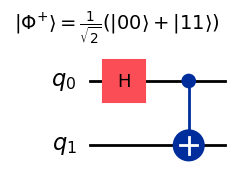

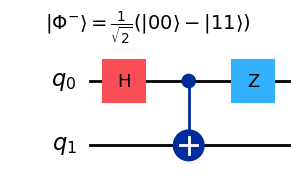

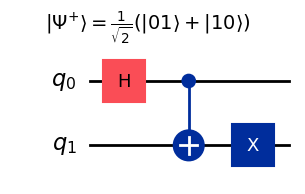

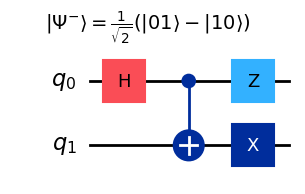

In [27]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

fig = qc.draw("mpl")

fig.suptitle(
    r"$|\Phi^{+}\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle + |11\rangle\right)$",
    fontsize=14
)

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.z(0)

fig = qc.draw("mpl")

fig.suptitle(
    r"$|\Phi^{-}\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle - |11\rangle\right)$",
    fontsize=14
)

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)

fig = qc.draw("mpl")

fig.suptitle(
    r"$|\Psi^{+}\rangle = \frac{1}{\sqrt{2}}\left(|01\rangle + |10\rangle\right)$",
    fontsize=14
)

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

fig = qc.draw("mpl")

fig.suptitle(
    r"$|\Psi^{-}\rangle = \frac{1}{\sqrt{2}}\left(|01\rangle - |10\rangle\right)$",
    fontsize=14
)


plt.show()

## 2c

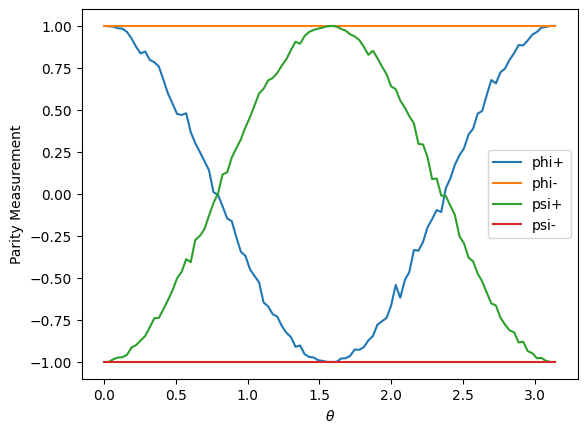

In [23]:
def bell_state(name):
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)

    if name == "phi-":
        qc.z(0)
    elif name == "psi+":
        qc.x(1)
    elif name == "psi-":
        qc.x(1)
        qc.z(0)
    return qc

def parity_from_counts(counts):
    even = counts.get('00',0) + counts.get('11',0)
    odd  = counts.get('01',0) + counts.get('10',0)
    return (even - odd)/(even + odd) if even + odd > 0 else 0

sampler = StatevectorSampler()
thetas = np.linspace(0, np.pi, 100)

results = {"phi+":[], "phi-":[], "psi+":[], "psi-":[]}

for name in results.keys():
    for theta in thetas:
        qc = bell_state(name)
        qc.rx(theta, 0)
        qc.rx(theta, 1)
        qc.measure([0,1],[0,1])

        job = sampler.run([qc], shots=1000)
        result = job.result()
        counts = result[0].data.c.get_counts()

        results[name].append(parity_from_counts(counts))

plt.figure()
for name in results:
    plt.plot(thetas, results[name], label=name)

plt.xlabel("$\\theta$")
plt.ylabel("Parity Measurement")
plt.legend()
plt.show()

## 6c.

Counts: {'1': 506, '0': 518}
Counts: {'1': 591, '0': 433}
Counts: {'1': 817, '0': 207}


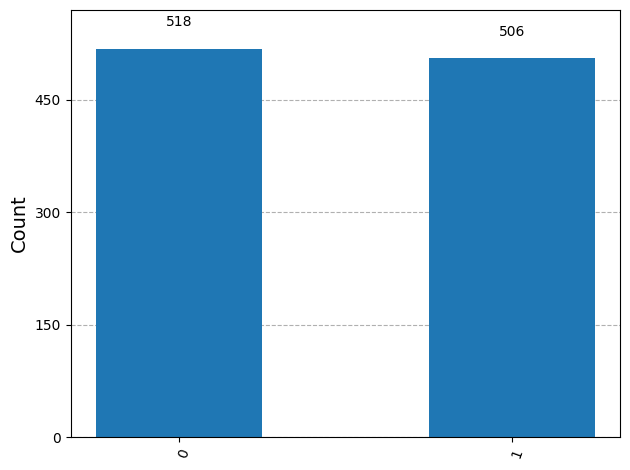

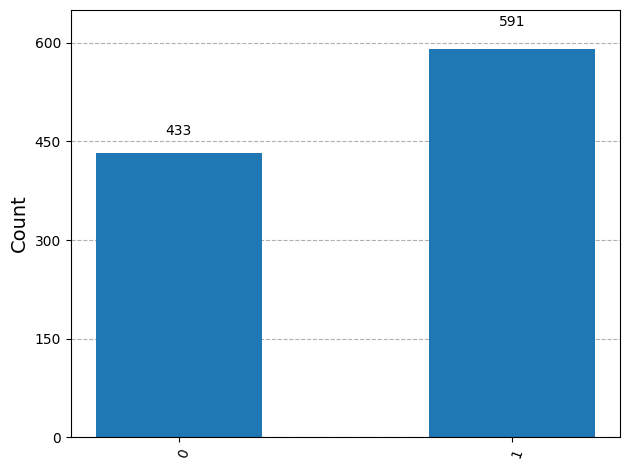

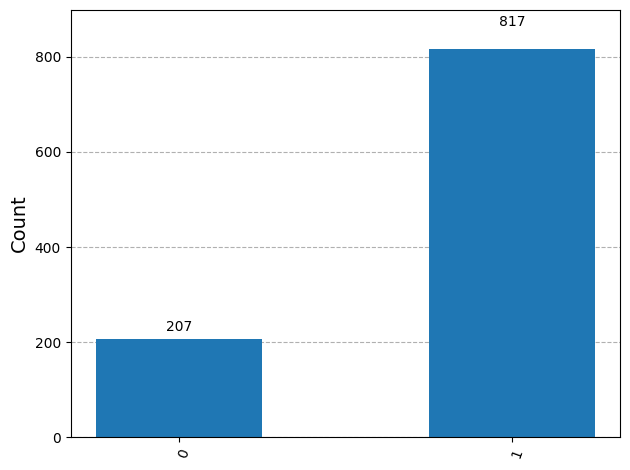

In [42]:
def teleport(qc):
    #prepare bell state
    qc.h(1)
    qc.cx(1,2)
    qc.z(1)
    qc.x(2)

    qc.cx(0,1)
    qc.h(0)

    qc.x(0)
    qc.x(1)
    qc.cx(1,2)
    qc.cz(0,2)
    qc.measure(2,0)
    return qc

def plot(qc):
    sampler = StatevectorSampler()
    result = sampler.run([qc], shots=1024).result()
    counts = result[0].data.c.get_counts()
    print('Counts:', counts)
    plot_histogram(counts);

# Teleport |+⟩
qc = QuantumCircuit(3,1)
qc.h(0)
qc = teleport(qc)
plot(qc)

# Teleport √0.4|0⟩ + √0.6|1⟩
qc = QuantumCircuit(3,1)
qc.initialize([np.sqrt(0.4), np.sqrt(0.6)], 0)
qc = teleport(qc)
plot(qc)

# Teleport √0.2|0⟩ + √0.8|1⟩
qc = QuantumCircuit(3,1)
qc.initialize([np.sqrt(0.2), np.sqrt(0.8)], 0)
qc = teleport(qc)
plot(qc)

## 6d.

In [44]:
# Teleport √0.2|0⟩ + √0.8|1⟩
qc = QuantumCircuit(3,1)
qc.initialize([np.sqrt(0.2), np.sqrt(0.8)], 0)
qc = teleport(qc)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = sampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="Quantum Teleportation on √0.2|0⟩ + √0.8|1⟩");

c:\Users\Daniel\Desktop\hw\.venv\Lib\site-packages\qiskit\circuit\quantumcircuit.py:4704: UserWarning: Trying to add QuantumRegister to a QuantumCircuit having a layout
  circ.add_register(qreg)


ValueError: Maximum allowed dimension exceeded